# Confusion Matrices

In [23]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Reusable Code for each FM

In [24]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ====================================================================
# Configuration
# ====================================================================
RESULTS_BASE = Path('/content/drive/MyDrive/infra_fm/results')

# (subdir, file_prefix, FM label, default cmap, protocol_key)
FM_CONFIGS = {
    'satlas_s1':      ('fm_eval_satlas_s1_finetune_v1',       'satlas_s1_finetune_v1',       'SatlasPretrain S1 (FT, 1.0×)',      'Oranges', 'finetune'),
    'satlas_s2':      ('fm_eval_satlas_s2_finetune_v1',       'satlas_s2_finetune_v1',       'SatlasPretrain S2 (FT, 1.0×)',      'Oranges', 'finetune'),
    'croma':          ('fm_eval_croma_finetune_v1',           'croma_finetune_v1',           'CROMA (FT, 1.0×)',                  'Oranges', 'finetune'),
    'prithvi':        ('fm_eval_prithvi_finetune_v1',         'prithvi_finetune_v1',         'Prithvi-EO-2.0 (FT, 1.0×)',         'Oranges', 'finetune'),
    'alphaearth':     ('fm_eval_alphaearth_v2_spatial',       'alphaearth_v2',               'AlphaEarth Foundations (LP, 1.0×)', 'Oranges', 'linear_probe'),
    'olmoearth':      ('fm_eval_olmoearth_finetune_v1',       'olmoearth_finetune_v1',       'OlmoEarth v1.1-Base (FT, 1.0×)',    'Oranges', 'finetune'),
    'dinov3':         ('fm_eval_dinov3_finetune_v1',          'dinov3_finetune_v1',          'DINOv3 ViT-L/16 (FT, 1.0×)',        'Oranges', 'finetune'),
    'resnet':         ('fm_eval_resnet18_supervised_v1',      'resnet18_supervised_v1',      'Supervised ResNet-18 (FT, 1.0×)',       'Oranges', 'linear_probe'), # saved as linear probe but its actually fine-tuned essentially
    'random_features':('fm_eval_resnet18_random_features_v1', 'resnet18_random_features_v1', 'Random Features (LP, 1.0×)',        'Oranges', 'linear_probe'),
}

CLASS_NAMES = [
    'energy.transmission.substation',
    'energy.distribution.substation',
    'energy.distribution.other',
    'energy.generation.power_plant',
    'energy.generation.solar_farm',
    'energy.generation.wind_farm',
    'water.wastewater.plant',
    'water.water_works',
    'water.storage_tank',
    'transport.airport',
    'transport.train_station',
    'transport.port_terminal',
    'telecom.data_center',
]

# Formal display names for figures (per Ed's feedback: no raw OSM-tag
# underscores/lowercase in plots -- use proper row/column labels).
CLASS_DISPLAY_NAMES = {
    'energy.transmission.substation': 'Transmission Substation',
    'energy.distribution.substation': 'Distribution Substation',
    'energy.distribution.other': 'Distribution (Other)',
    'energy.generation.power_plant': 'Power Plant',
    'energy.generation.solar_farm': 'Solar Farm',
    'energy.generation.wind_farm': 'Wind Farm',
    'water.wastewater.plant': 'Wastewater Plant',
    'water.water_works': 'Water Works',
    'water.storage_tank': 'Storage Tank',
    'transport.airport': 'Airport',
    'transport.train_station': 'Train Station',
    'transport.port_terminal': 'Port Terminal',
    'telecom.data_center': 'Data Center',
}
SHORT_NAMES = [CLASS_DISPLAY_NAMES[n] for n in CLASS_NAMES]
DEFAULT_SEEDS = [314, 271, 161]

# Legacy class-name remap. `water.treatment.plant` was the previous name
# for what is now `water.water_works` (ontology.py rename). Aggregate
# JSONs produced before the rename still carry the old string on
# `per_class_f1[i]['class']`. Per-seed JSONs use index-based float lists
# (no class-name strings), so this remap is only needed by code that
# keys aggregate JSONs by class-name string. Safe to call repeatedly.
LEGACY_CLASS_REMAP = {'water.treatment.plant': 'water.water_works'}


def apply_legacy_class_remap(agg):
    """Rewrite legacy class-name strings in an aggregate JSON in place.
    No-op on already-renamed aggregates. Returns the same dict for chaining.
    """
    for entry in agg.get('per_class_f1', []):
        if entry.get('class') in LEGACY_CLASS_REMAP:
            entry['class'] = LEGACY_CLASS_REMAP[entry['class']]
    return agg


# ====================================================================
# Internal helpers
# ====================================================================
def _load_seed_results(fm, seeds):
    """Load per-seed JSONs for a given FM. Returns (data, missing, label, default_cmap)."""
    if fm not in FM_CONFIGS:
        raise ValueError(
            f'Unknown FM "{fm}". Available: {list(FM_CONFIGS.keys())}'
        )
    subdir, file_prefix, fm_label, default_cmap, protocol_key = FM_CONFIGS[fm]
    results_dir = RESULTS_BASE / subdir

    seed_data = {}
    missing = []
    for seed in seeds:
        json_path = results_dir / f'{file_prefix}_seed{seed}_results.json'
        if not json_path.exists():
            missing.append(seed)
            continue
        with open(json_path) as f:
            r = json.load(f)
        test = r[protocol_key]['test']
        cm = np.array(test['confusion'], dtype=np.int64)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm.astype(np.float64), row_sums,
                             out=np.zeros_like(cm, dtype=np.float64),
                             where=row_sums > 0)
        seed_data[seed] = {
            'cm': cm,
            'cm_norm': cm_norm,
            'macro_f1': test['macro_f1'],
            'acc': test['acc'],
            'n': int(cm.sum()),
            'per_class_f1': test['per_class_f1'],
        }
    return seed_data, missing, fm_label, default_cmap


def _draw_confusion(ax, cm, cm_norm, title, cmap='Oranges'):
    """Draw a single confusion matrix on a given axes."""
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(SHORT_NAMES, rotation=45, ha='right', fontsize=14)
    ax.set_yticklabels(SHORT_NAMES, fontsize=14)
    ax.set_xlabel('Predicted', fontsize=17)
    ax.set_ylabel('True', fontsize=17)
    ax.set_title(title, fontsize=18)
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            v = cm_norm[i, j]
            count = cm[i, j]
            if v > 0.01:
                color = 'white' if v > 0.5 else 'black'
                ax.text(j, i, f'{count}\n({v:.0%})', ha='center', va='center',
                        color=color, fontsize=12)
    return im


def _print_summary(seed_data, seeds, fm_label):
    """Print per-class and macro F1 summary across seeds."""
    n_seeds = len(seeds)
    print(f'\n{fm_label} v2 — per-class F1 across {n_seeds} seed(s): {seeds}')
    header_seeds = '  '.join([f'{f"seed {s}":<10s}' for s in seeds])
    summary_col = '  mean ± std' if n_seeds >= 2 else ''
    print(f'{"":<3} {"class":<34s} {header_seeds}{summary_col}')
    print('-' * (38 + 12 * n_seeds + (15 if n_seeds >= 2 else 0)))
    for i, name in enumerate(CLASS_NAMES):
        vals = [seed_data[s]['per_class_f1'][i] for s in seeds]
        row = (f'[{i:>2d}] {name:<34s} '
               + '  '.join([f'{v:<10.4f}' for v in vals]))
        if n_seeds >= 2:
            m, sd = float(np.mean(vals)), float(np.std(vals, ddof=0))
            row += f'  {m:.4f} ± {sd:.4f}'
        print(row)

    macros = [seed_data[s]['macro_f1'] for s in seeds]
    print(f'\nMacro F1 across seeds: {[f"{m:.4f}" for m in macros]}')
    if n_seeds >= 2:
        print(f'Mean ± std:           '
              f'{np.mean(macros):.4f} ± {np.std(macros, ddof=0):.4f}')



# ====================================================================
# Aggregate confusion matrix (main paper figure)
# ====================================================================
def confusion_matrix_aggregate(fm, seeds=None, show_summary=True, cmap=None):
    """
    Display a single aggregate confusion matrix for an FM by summing
    raw counts across seeds before row-normalizing.

    Use this for the main paper body. Use confusion_matrix() for the
    per-seed appendix figures. Use save_all_confusion_matrices() to
    write PNGs to disk for all FMs at once.

    Parameters
    ----------
    fm : str
        FM key in FM_CONFIGS.
    seeds : list[int] or None
        Seeds to aggregate over. Defaults to [314, 271, 161].
    show_summary : bool
        If True, prints per-class F1 summary.
    cmap : str or None
        Matplotlib colormap. Falls back to per-FM default.

    Returns
    -------
    seed_data : dict
        Loaded per-seed data.
    """
    if seeds is None:
        seeds = DEFAULT_SEEDS

    seed_data, missing, fm_label, default_cmap = _load_seed_results(fm, seeds)
    if missing:
        print(f'NOTE: missing seeds {missing} for {fm_label} — '
              f'showing available seeds only')

    available_seeds = [s for s in seeds if s in seed_data]
    n_seeds = len(available_seeds)
    if n_seeds == 0:
        raise RuntimeError(
            f'No seed results found for {fm_label}. '
            f'Checked: {RESULTS_BASE / FM_CONFIGS[fm][0]}'
        )

    effective_cmap = cmap if cmap is not None else default_cmap

    # Sum raw counts across seeds, then row-normalize once.
    # This is correct -- do NOT average normalized matrices.
    cm_sum = sum(seed_data[s]['cm'] for s in available_seeds)
    row_sums = cm_sum.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_sum.astype(np.float64), row_sums,
                         out=np.zeros_like(cm_sum, dtype=np.float64),
                         where=row_sums > 0)

    # Aggregate macro F1: mean of per-seed macro F1 scores
    macro_f1_mean = float(np.mean([seed_data[s]['macro_f1'] for s in available_seeds]))
    macro_f1_std  = float(np.std( [seed_data[s]['macro_f1'] for s in available_seeds], ddof=0))
    n_total = int(cm_sum.sum())

    title = (f'n={n_total} across {n_seeds} seeds\n'
             f'macro F1={macro_f1_mean:.3f} ± {macro_f1_std:.3f}')

    fig, ax = plt.subplots(1, 1, figsize=(13, 12.5),
                           constrained_layout=True)
    im = _draw_confusion(ax, cm_sum, cm_norm, title, cmap=effective_cmap)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                 label='Row-normalized')
    fig.suptitle(f'{fm_label} — Aggregate Confusion Matrix',
                 fontsize=20, y=1.01)
    plt.show()

    if show_summary:
        _print_summary(seed_data, available_seeds, fm_label)

    return seed_data


# ====================================================================
# Public entry point
# ====================================================================
def confusion_matrix(fm, seeds=None, show_summary=True, cmap=None):
    """
    Display per-seed confusion matrices stacked vertically for an FM.

    Parameters
    ----------
    fm : str
        FM key in FM_CONFIGS. Options: 'croma', 'alphaearth', 'satlas_s1',
        'satlas_s2', 'prithvi', 'resnet'.
    seeds : list[int] or None
        Seeds to display. Defaults to [314, 271, 161]. Missing seeds
        are silently skipped with a note.
    show_summary : bool
        If True, prints per-class F1 table across seeds + macro F1
        summary after the plot.
    cmap : str or None
        Matplotlib colormap name. If None, uses the per-FM default
        from FM_CONFIGS.

    Returns
    -------
    seed_data : dict
        Loaded per-seed data, in case you want further analysis.
    """
    if seeds is None:
        seeds = DEFAULT_SEEDS

    seed_data, missing, fm_label, default_cmap = _load_seed_results(fm, seeds)
    if missing:
        print(f'NOTE: missing seeds {missing} for {fm_label} — '
              f'showing available seeds only')

    available_seeds = [s for s in seeds if s in seed_data]
    n_seeds = len(available_seeds)
    if n_seeds == 0:
        raise RuntimeError(
            f'No seed results found for {fm_label}. '
            f'Checked: {RESULTS_BASE / FM_CONFIGS[fm][0]}'
        )

    effective_cmap = cmap if cmap is not None else default_cmap

    # One figure per seed -- easier to place individually in the manuscript.
    for k, seed in enumerate(available_seeds):
        d = seed_data[seed]
        title = (
                 f'n={d["n"]}, macro F1={d["macro_f1"]:.3f}, '
                 f'acc={d["acc"]:.3f}')

        fig, ax = plt.subplots(1, 1, figsize=(13, 12.5),
                               constrained_layout=True)
        im = _draw_confusion(ax, d['cm'], d['cm_norm'], title,
                              cmap=effective_cmap)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                     label='Row-normalized')
        fig.suptitle(f'{fm_label} — Seed {seed} Confusion Matrix',
                     fontsize=20, y=1.01)
        plt.show()

    if show_summary:
        _print_summary(seed_data, available_seeds, fm_label)

    return seed_data


# ====================================================================
# Bulk save-to-disk (Task 3: regenerate all figures with 'Water Works')
# ====================================================================
def save_all_confusion_matrices(fms=None, seeds=None, cmap='Oranges',
                                dpi=150, verbose=True):
    """Write every confusion-matrix PNG (aggregate + per-seed) for every FM
    to that FM's results directory. Does NOT render inline — this is the
    write-to-disk path. Use confusion_matrix() / confusion_matrix_aggregate()
    for inline preview.

    Filenames written into each `RESULTS_BASE / FM_CONFIGS[fm].subdir`:
      - confusion_matrix_{file_prefix}_aggregate.png   (1 per FM)
      - confusion_matrix_{file_prefix}_seed{seed}.png  (1 per seed)

    So a full run (6 FMs × 3 seeds + 6 aggregates) writes 24 PNGs.

    Parameters
    ----------
    fms : list[str] or None
        FM keys to render. Defaults to all six in FM_CONFIGS.
    seeds : list[int] or None
        Seeds to render. Defaults to [314, 271, 161].
    cmap : str
        Matplotlib colormap. Defaults to 'Oranges' (manuscript style).
    dpi : int
        Save resolution. 150 matches the training-notebook default.
    verbose : bool
        Print each save path.

    Returns
    -------
    list of (Path, str) tuples: (written_path, status) where status is
    'aggregate' or 'seed{n}'. Empty list if nothing was writable.
    """
    if fms is None:
        fms = list(FM_CONFIGS.keys())
    if seeds is None:
        seeds = DEFAULT_SEEDS

    written = []
    for fm in fms:
        subdir, file_prefix, fm_label, _, _ = FM_CONFIGS[fm]
        out_dir = RESULTS_BASE / subdir
        out_dir.mkdir(parents=True, exist_ok=True)

        seed_data, missing, _, _ = _load_seed_results(fm, seeds)
        if missing:
            print(f'[{fm_label}] missing seeds {missing} — skipping those')
        available = [s for s in seeds if s in seed_data]
        if not available:
            print(f'[{fm_label}] NO SEEDS AVAILABLE at {out_dir} — skipping FM')
            continue

        # --- Per-seed figures ---
        for seed in available:
            d = seed_data[seed]
            title = (
                     f'n={d["n"]}, macro F1={d["macro_f1"]:.3f}, '
                     f'acc={d["acc"]:.3f}')
            fig, ax = plt.subplots(1, 1, figsize=(13, 12.5),
                                   constrained_layout=True)
            im = _draw_confusion(ax, d['cm'], d['cm_norm'], title, cmap=cmap)
            fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                         label='Row-normalized')
            fig.suptitle(f'{fm_label} — Seed {seed} Confusion Matrix',
                         fontsize=20, y=1.01)
            path = out_dir / f'confusion_matrix_{file_prefix}_seed{seed}.png'
            fig.savefig(path, dpi=dpi, bbox_inches='tight')
            plt.close(fig)
            written.append((path, f'seed{seed}'))
            if verbose:
                print(f'  saved  {path}')

        # --- Aggregate figure ---
        cm_sum = sum(seed_data[s]['cm'] for s in available)
        row_sums = cm_sum.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm_sum.astype(np.float64), row_sums,
                             out=np.zeros_like(cm_sum, dtype=np.float64),
                             where=row_sums > 0)
        macros = [seed_data[s]['macro_f1'] for s in available]
        macro_mean = float(np.mean(macros))
        macro_std  = float(np.std(macros, ddof=0))
        title = (f'n={int(cm_sum.sum())} across {len(available)} seeds\n'
                 f'macro F1={macro_mean:.3f} ± {macro_std:.3f}')
        fig, ax = plt.subplots(1, 1, figsize=(13, 12.5),
                               constrained_layout=True)
        im = _draw_confusion(ax, cm_sum, cm_norm, title, cmap=cmap)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02,
                     label='Row-normalized')
        fig.suptitle(f'{fm_label} — Aggregate Confusion Matrix',
                     fontsize=20, y=1.01)
        path = out_dir / f'confusion_matrix_{file_prefix}_aggregate.png'
        fig.savefig(path, dpi=dpi, bbox_inches='tight')
        plt.close(fig)
        written.append((path, 'aggregate'))
        if verbose:
            print(f'  saved  {path}\n')

    print(f'\nDone. Wrote {len(written)} PNG(s) across {len(fms)} FMs.')
    n_agg  = sum(1 for _, s in written if s == 'aggregate')
    n_seed = sum(1 for _, s in written if s.startswith('seed'))
    print(f'  aggregate: {n_agg}   per-seed: {n_seed}')
    return written


# ============================================================================
# Precision / recall / weighted-F1 helper
# ============================================================================
def compute_precision_recall_from_confusion(cm):
    """Per-class precision, recall, F1, plus weighted-F1 / macro-F1 / accuracy,
    computed from a confusion matrix.

    Verified against sklearn's precision_recall_fscore_support to <1e-10 on
    non-degenerate CMs (see the notebook's git history for the self-test).
    Zero-division-safe: any class with zero support gets recall=0/f1=0, and
    any class never predicted gets precision=0/f1=0.

    Parameters
    ----------
    cm : array-like of shape (n_classes, n_classes)
        cm[i, j] = count of samples with true class i predicted as class j.
        Diagonal = TP; row sums = support (true class); col sums = predicted.

    Returns
    -------
    dict with:
        'precision'   : np.ndarray (n_classes,) — TP / (TP + FP)
        'recall'      : np.ndarray (n_classes,) — TP / (TP + FN)
        'f1'          : np.ndarray (n_classes,) — 2·P·R / (P + R)
        'support'     : np.ndarray[int64] (n_classes,) — per-class row sum
        'weighted_f1' : float — Σ_c (support_c / total) · f1_c
        'macro_f1'    : float — mean(f1)
        'accuracy'    : float — sum(diag) / total
        'n_classes'   : int
        'total'       : int — sum of all CM entries
    """
    cm = np.asarray(cm, dtype=np.float64)
    if cm.ndim != 2 or cm.shape[0] != cm.shape[1]:
        raise ValueError(f'cm must be square 2-D; got shape {cm.shape}')
    n_classes = cm.shape[0]
    tp        = np.diag(cm)
    support   = cm.sum(axis=1)              # true-class counts (row sums)
    predicted = cm.sum(axis=0)              # predicted-class counts (col sums)
    precision = np.divide(tp, predicted, out=np.zeros(n_classes), where=predicted > 0)
    recall    = np.divide(tp, support,   out=np.zeros(n_classes), where=support   > 0)
    pr_sum    = precision + recall
    f1        = np.divide(2 * precision * recall, pr_sum,
                          out=np.zeros(n_classes), where=pr_sum > 0)
    total     = cm.sum()
    if total > 0:
        weights     = support / total
        weighted_f1 = float((weights * f1).sum())
        accuracy    = float(tp.sum() / total)
    else:
        weighted_f1 = 0.0
        accuracy    = 0.0
    return {
        'precision':   precision,
        'recall':      recall,
        'f1':          f1,
        'support':     support.astype(np.int64),
        'weighted_f1': weighted_f1,
        'macro_f1':    float(f1.mean()),
        'accuracy':    accuracy,
        'n_classes':   int(n_classes),
        'total':       int(total),
    }



## Per-seed Matrices

### Satlas S1

In [ ]:
confusion_matrix('satlas_s1', cmap="Oranges")

### Satlas S2

In [ ]:
confusion_matrix('satlas_s2', cmap="Oranges")

### CROMA 

In [ ]:
confusion_matrix('croma', cmap="Oranges")

### AlphaEarth

In [ ]:
confusion_matrix('alphaearth', cmap="Oranges")

### Prithvi

In [ ]:
confusion_matrix('prithvi', cmap="Oranges")

### OlmoEarth

In [ ]:
confusion_matrix('olmoearth', cmap="Oranges")

### DINOv3

In [ ]:
confusion_matrix('dinov3', cmap="Oranges")

### ResNet-18

In [ ]:
confusion_matrix('resnet', cmap='Oranges')

### Random Features

In [ ]:
confusion_matrix('random_features', cmap='Oranges')

## Aggregate Confusion Matrices (main paper figures)

One figure per FM: raw counts summed across all three seeds, then row-normalized.

### Satlas S1

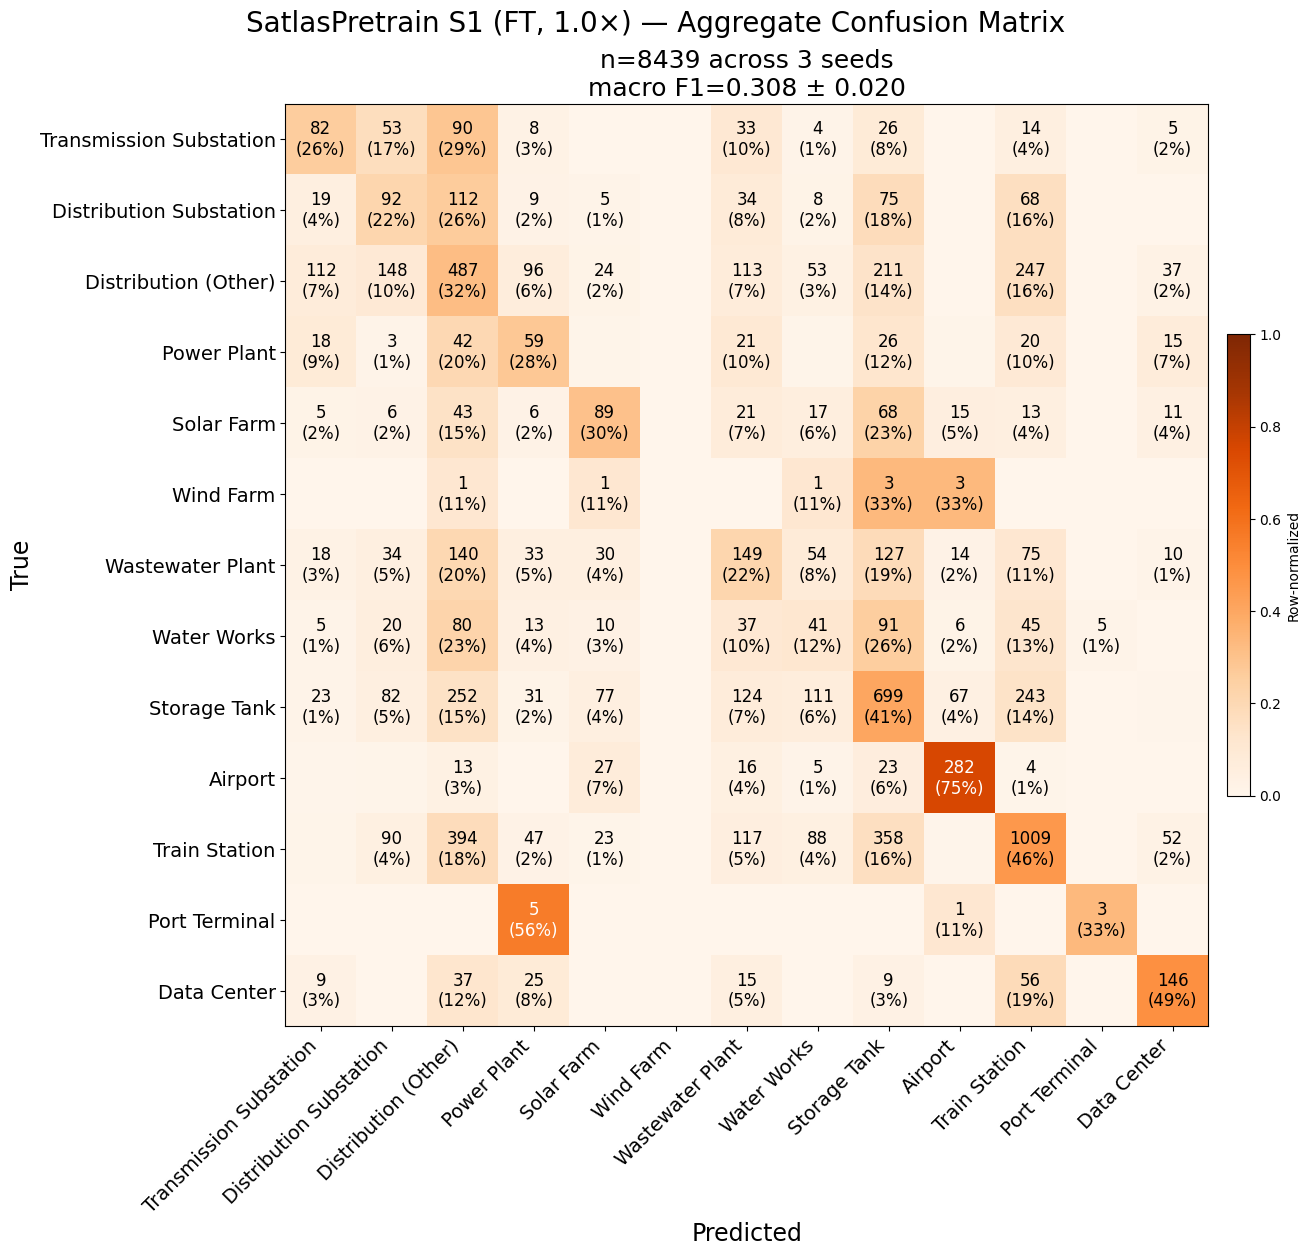


SatlasPretrain S1 (FT, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.2707      0.2540      0.2514      0.2587 ± 0.0085
[ 1] energy.distribution.substation     0.2182      0.1760      0.1747      0.1896 ± 0.0202
[ 2] energy.distribution.other          0.2738      0.3067      0.3271      0.3026 ± 0.0219
[ 3] energy.generation.power_plant      0.2083      0.2146      0.2345      0.2192 ± 0.0111
[ 4] energy.generation.solar_farm       0.3258      0.2888      0.2971      0.3039 ± 0.0159
[ 5] energy.generation.wind_farm        0.0000      0.0000      0.0000      0.0000 ± 0.0000
[ 6] water.wastewater.plant             0.1896      0.2259      0.2291      0.2149 ± 0.0179
[ 7] water.water_works                  0.1130      0.0949      0.1250      0.1110 ± 0.0124
[ 8] w

{314: {'cm': array([[ 36,  20,  21,   5,   0,   0,   6,   0,  10,   0,   3,   0,   4],
         [ 11,  42,  30,   3,   3,   0,   3,   2,  26,   0,  20,   0,   1],
         [ 54,  69, 148,  37,  11,   0,  15,   8,  66,   2,  77,   0,  24],
         [ 10,   1,  12,  20,   1,   0,   4,   0,   6,   1,   7,   0,   8],
         [  2,   3,  16,   4,  36,   0,   2,   0,  22,   7,   0,   0,   6],
         [  0,   0,   0,   0,   0,   0,   0,   0,   2,   1,   0,   0,   0],
         [ 10,  16,  45,  15,   9,   0,  31,  11,  53,   8,  24,   0,   6],
         [  4,  10,  32,   4,   4,   0,   8,  10,  31,   4,  10,   0,   1],
         [ 14,  38,  90,  14,  37,   0,  14,  16, 235,  29,  77,   0,  10],
         [  1,   2,   8,   0,  10,   0,   0,   0,   4, 100,   0,   0,   0],
         [ 14,  43, 156,  15,  12,   0,  15,  12, 133,   7, 293,   0,  37],
         [  0,   0,   0,   2,   0,   0,   0,   0,   0,   1,   0,   0,   0],
         [  5,   0,  12,   3,   0,   0,   1,   0,   0,   0,  10,   0,  69]]),

In [4]:
confusion_matrix_aggregate('satlas_s1', cmap='Oranges')

### Satlas S2

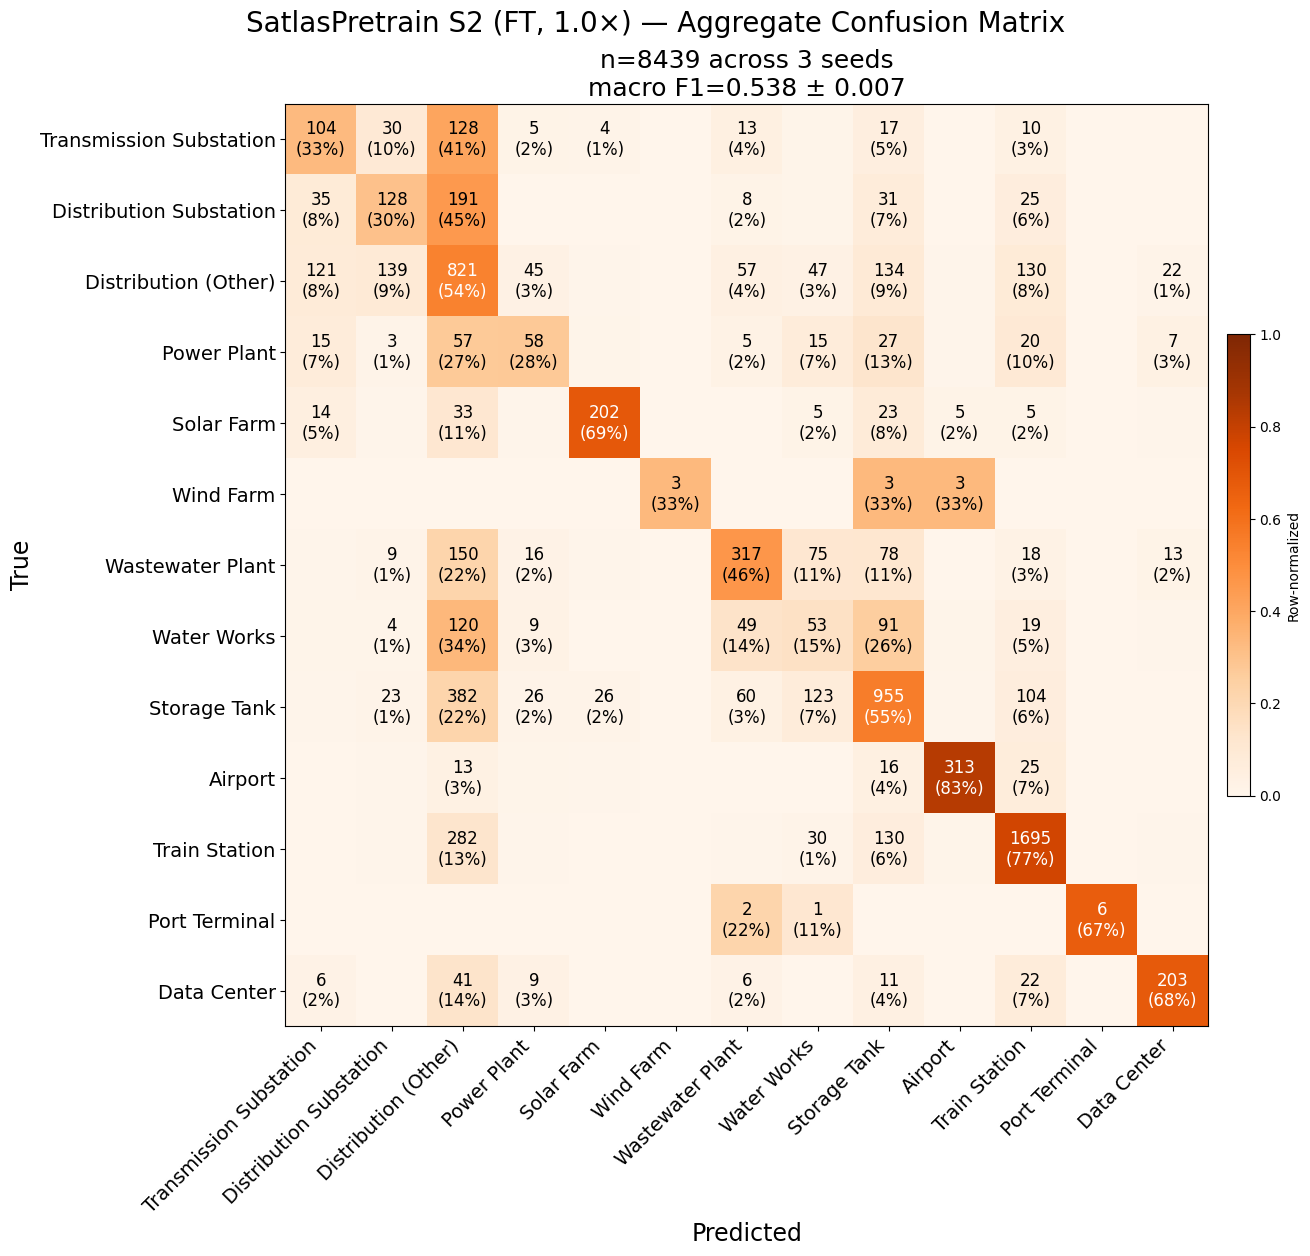


SatlasPretrain S2 (FT, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.3021      0.3682      0.3290      0.3331 ± 0.0271
[ 1] energy.distribution.substation     0.3534      0.3234      0.3129      0.3299 ± 0.0172
[ 2] energy.distribution.other          0.4482      0.4586      0.4064      0.4377 ± 0.0226
[ 3] energy.generation.power_plant      0.3065      0.2881      0.2876      0.2941 ± 0.0088
[ 4] energy.generation.solar_farm       0.7385      0.7312      0.7251      0.7316 ± 0.0054
[ 5] energy.generation.wind_farm        0.5000      0.5000      0.5000      0.5000 ± 0.0000
[ 6] water.wastewater.plant             0.4974      0.5501      0.5219      0.5232 ± 0.0215
[ 7] water.water_works                  0.1747      0.1339      0.1401      0.1496 ± 0.0179
[ 8] w

{314: {'cm': array([[ 29,  12,  43,   2,   2,   0,   4,   2,   8,   0,   3,   0,   0],
         [  9,  44,  65,   0,   0,   0,   3,   2,  12,   0,   6,   0,   0],
         [ 38,  39, 279,  10,   5,   0,  18,  17,  53,   1,  43,   1,   7],
         [  4,   1,  22,  19,   1,   0,   2,   5,   8,   0,   6,   0,   2],
         [  3,   0,  10,   0,  72,   0,   1,   2,   6,   2,   2,   0,   0],
         [  0,   0,   0,   0,   0,   1,   0,   0,   1,   1,   0,   0,   0],
         [  0,   2,  50,   7,   2,   0,  97,  23,  39,   0,   5,   0,   3],
         [  1,   2,  34,   4,   1,   0,  15,  20,  33,   1,   6,   0,   1],
         [  1,   3, 115,   7,   9,   0,  17,  32, 343,   6,  41,   0,   0],
         [  0,   1,   3,   1,   1,   0,   0,   0,   5, 104,  10,   0,   0],
         [  0,   4,  98,   2,   3,   0,   2,   8,  47,   7, 563,   0,   3],
         [  0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   2,   0],
         [  2,   0,  15,   2,   1,   0,   2,   0,   4,   0,   7,   0,  67]]),

In [5]:
confusion_matrix_aggregate('satlas_s2', cmap='Oranges')

### CROMA

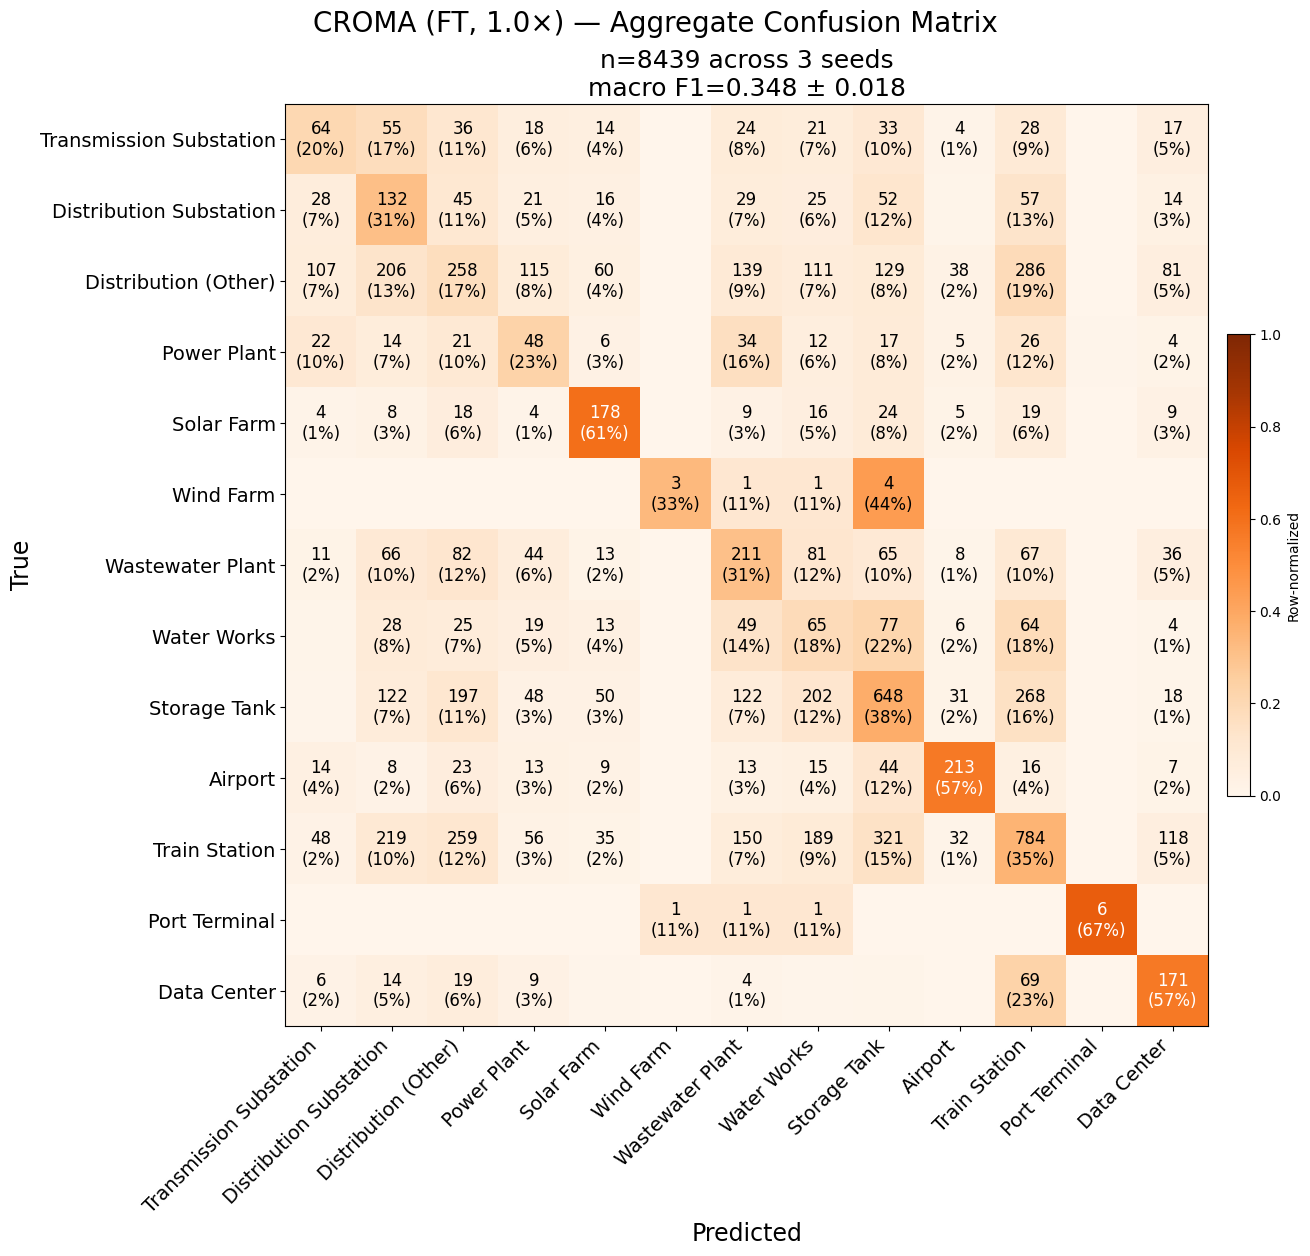


CROMA (FT, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.2367      0.1884      0.1746      0.1999 ± 0.0266
[ 1] energy.distribution.substation     0.1989      0.2044      0.2070      0.2035 ± 0.0034
[ 2] energy.distribution.other          0.2659      0.2139      0.0838      0.1878 ± 0.0766
[ 3] energy.generation.power_plant      0.2207      0.1439      0.1371      0.1672 ± 0.0379
[ 4] energy.generation.solar_farm       0.5816      0.4841      0.4959      0.5205 ± 0.0435
[ 5] energy.generation.wind_farm        0.3333      0.5000      0.2500      0.3611 ± 0.1039
[ 6] water.wastewater.plant             0.3178      0.2680      0.2808      0.2889 ± 0.0211
[ 7] water.water_works                  0.1677      0.0988      0.1000      0.1222 ± 0.0322
[ 8] water.storage

{314: {'cm': array([[ 29,  11,  22,   3,   3,   0,   8,   6,   8,   0,  13,   0,   2],
         [ 18,  36,  26,   3,   1,   0,   7,   5,  16,   1,  25,   0,   3],
         [ 47,  48, 142,  19,  12,   0,  35,  31,  45,   4, 112,   0,  16],
         [  9,   2,  11,  16,   3,   0,   8,   5,   4,   2,   9,   0,   1],
         [  1,   2,  13,   1,  57,   0,   2,   6,   5,   1,  10,   0,   0],
         [  0,   0,   0,   0,   0,   1,   1,   0,   1,   0,   0,   0,   0],
         [  5,  17,  43,  10,   2,   0,  68,  25,  21,   2,  28,   0,   7],
         [  0,   9,  15,   2,   2,   0,   8,  26,  28,   2,  26,   0,   0],
         [  5,  42, 110,   8,  11,   1,  23,  42, 219,   8, 101,   0,   4],
         [  2,   1,  12,   2,   2,   0,   1,   5,  11,  80,   9,   0,   0],
         [ 21,  50, 150,  11,   4,   0,  38,  39,  82,   8, 323,   0,  11],
         [  0,   0,   0,   0,   0,   1,   0,   1,   0,   0,   0,   1,   0],
         [  3,   3,  13,   0,   1,   0,   1,   1,   3,   1,  36,   0,  38]]),

In [6]:
confusion_matrix_aggregate('croma', cmap='Oranges')

### AlphaEarth

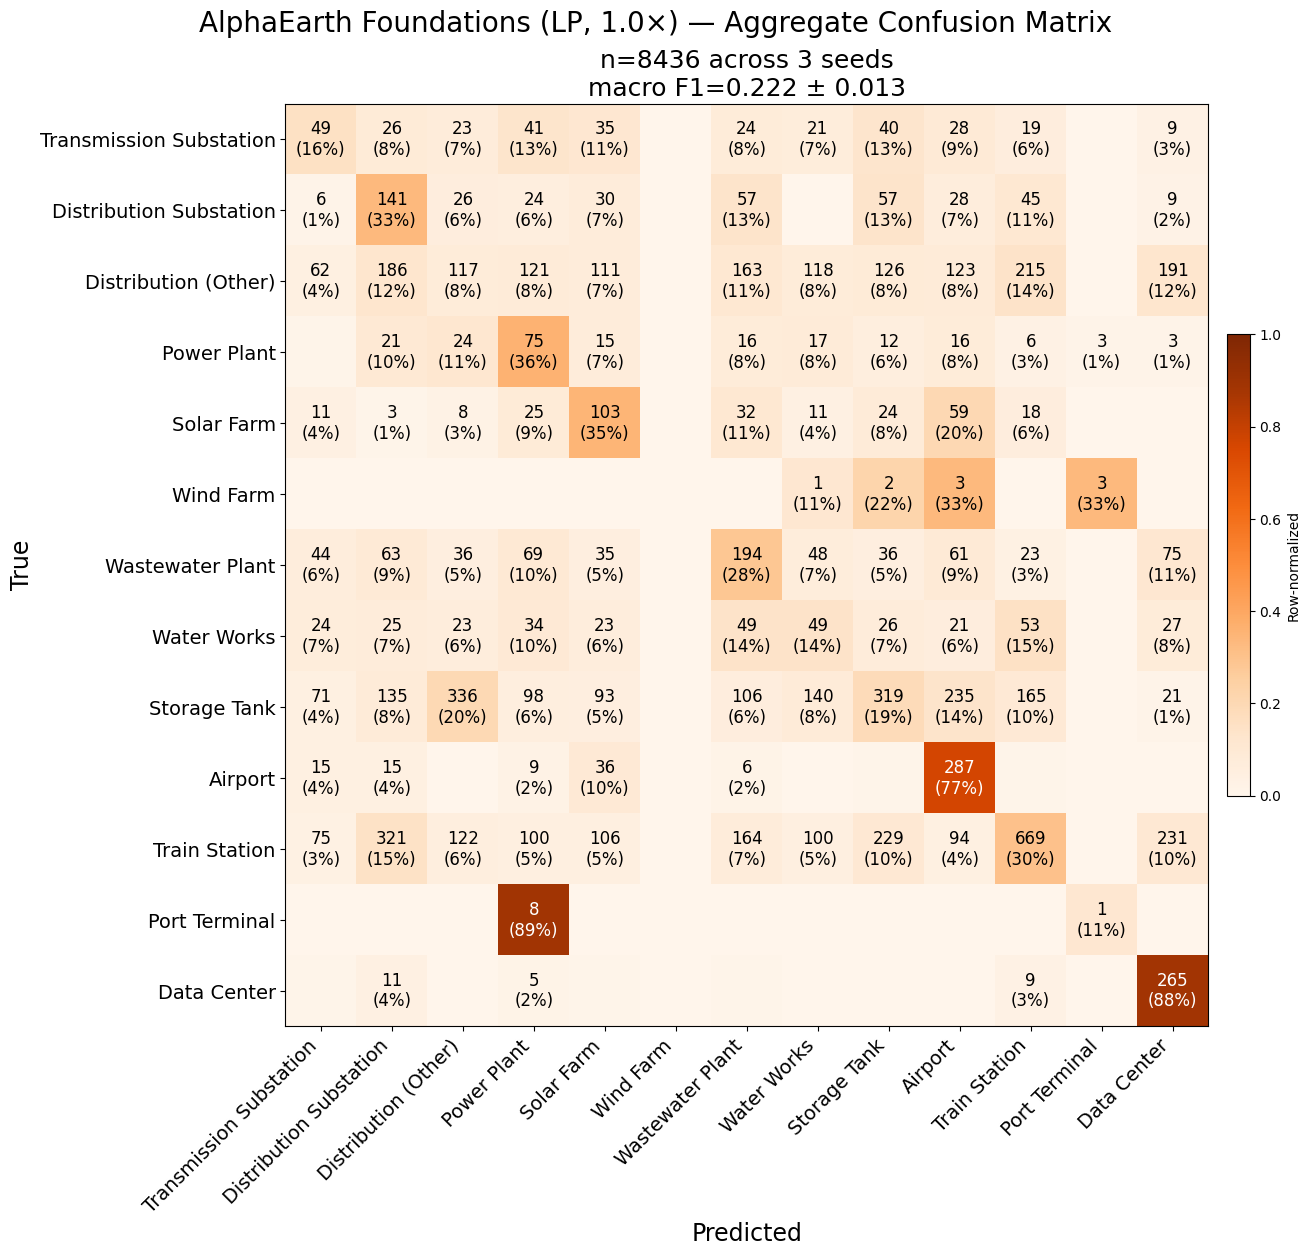


AlphaEarth Foundations (LP, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.1500      0.1475      0.1364      0.1446 ± 0.0059
[ 1] energy.distribution.substation     0.2039      0.2092      0.2044      0.2058 ± 0.0024
[ 2] energy.distribution.other          0.1058      0.1034      0.1028      0.1040 ± 0.0013
[ 3] energy.generation.power_plant      0.1860      0.1812      0.1825      0.1832 ± 0.0021
[ 4] energy.generation.solar_farm       0.2290      0.2416      0.2284      0.2330 ± 0.0061
[ 5] energy.generation.wind_farm        0.0000      0.0000      0.0000      0.0000 ± 0.0000
[ 6] water.wastewater.plant             0.2685      0.2531      0.2551      0.2589 ± 0.0068
[ 7] water.water_works                  0.1168      0.1119      0.1137      0.1141 ± 0.0020
[

{314: {'cm': array([[ 18,   7,   8,  12,  13,   0,   8,   7,  14,   9,   6,   0,   3],
         [  2,  47,   8,   8,  10,   0,  20,   0,  19,   9,  15,   0,   3],
         [ 23,  63,  40,  38,  36,   0,  58,  35,  44,  40,  70,   0,  64],
         [  1,   7,   8,  24,   5,   0,   7,   5,   4,   5,   2,   1,   1],
         [  6,   1,   2,   6,  34,   0,  11,   4,   8,  20,   6,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   0,   1,   0],
         [ 17,  20,  11,  21,  12,   0,  69,  14,  11,  20,   8,   0,  25],
         [  8,   8,   8,  12,   8,   0,  17,  16,   8,   7,  17,   0,   9],
         [ 26,  46, 114,  30,  32,   0,  37,  44, 109,  76,  52,   0,   7],
         [  5,   5,   0,   3,  13,   0,   2,   0,   1,  94,   1,   0,   1],
         [ 28, 111,  45,  30,  35,   0,  56,  31,  77,  31, 217,   0,  76],
         [  0,   0,   0,   3,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  1,   5,   1,   1,   1,   0,   1,   0,   0,   0,   3,   0,  87]]),

In [7]:
confusion_matrix_aggregate('alphaearth', cmap='Oranges')

### Prithvi

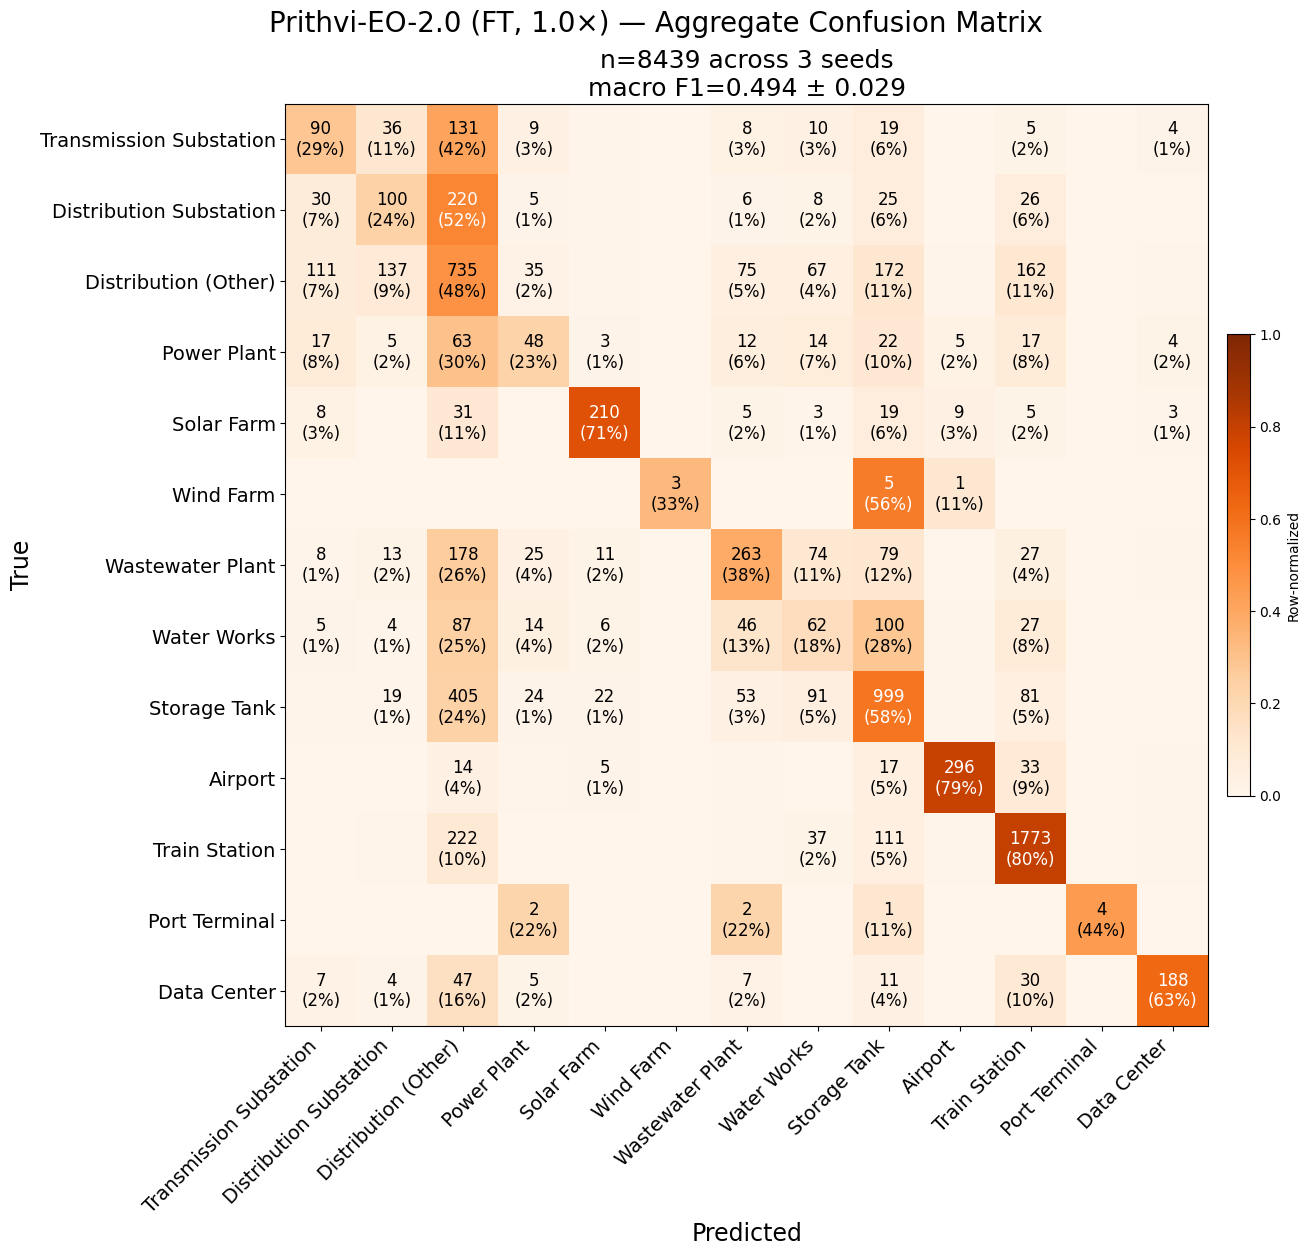


Prithvi-EO-2.0 (FT, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.2786      0.2784      0.3382      0.2984 ± 0.0281
[ 1] energy.distribution.substation     0.3038      0.2520      0.2462      0.2673 ± 0.0259
[ 2] energy.distribution.other          0.4067      0.4118      0.3838      0.4008 ± 0.0122
[ 3] energy.generation.power_plant      0.2857      0.2273      0.2333      0.2488 ± 0.0262
[ 4] energy.generation.solar_farm       0.7166      0.7619      0.6961      0.7249 ± 0.0275
[ 5] energy.generation.wind_farm        0.3333      0.5000      0.5000      0.4444 ± 0.0786
[ 6] water.wastewater.plant             0.4450      0.4557      0.4399      0.4469 ± 0.0066
[ 7] water.water_works                  0.1600      0.1872      0.1695      0.1722 ± 0.0113
[ 8] wate

{314: {'cm': array([[ 28,  11,  46,   2,   1,   0,   4,   4,   5,   0,   2,   0,   2],
         [  9,  36,  75,   1,   1,   0,   1,   4,   5,   0,   9,   0,   0],
         [ 42,  38, 256,  13,   4,   0,  26,  20,  50,   2,  54,   0,   6],
         [  5,   1,  22,  19,   1,   0,   4,   4,   5,   2,   5,   0,   2],
         [  2,   0,  13,   0,  67,   0,   3,   1,   7,   3,   1,   0,   1],
         [  0,   0,   0,   0,   0,   1,   0,   0,   2,   0,   0,   0,   0],
         [  4,   1,  60,  11,   4,   0,  87,  27,  21,   1,  10,   0,   2],
         [  1,   2,  31,   3,   2,   0,  12,  20,  35,   1,  11,   0,   0],
         [  2,   3, 146,  10,   5,   1,  18,  40, 323,   6,  20,   0,   0],
         [  1,   0,   4,   0,   1,   1,   2,   0,   4,  99,  13,   0,   0],
         [  1,   2,  77,   3,   3,   0,   3,  11,  33,   5, 594,   0,   5],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0],
         [  1,   2,  18,   1,   0,   0,   3,   1,   3,   0,  10,   0,  61]]),

In [8]:
confusion_matrix_aggregate('prithvi', cmap='Oranges')

### OlmoEarth

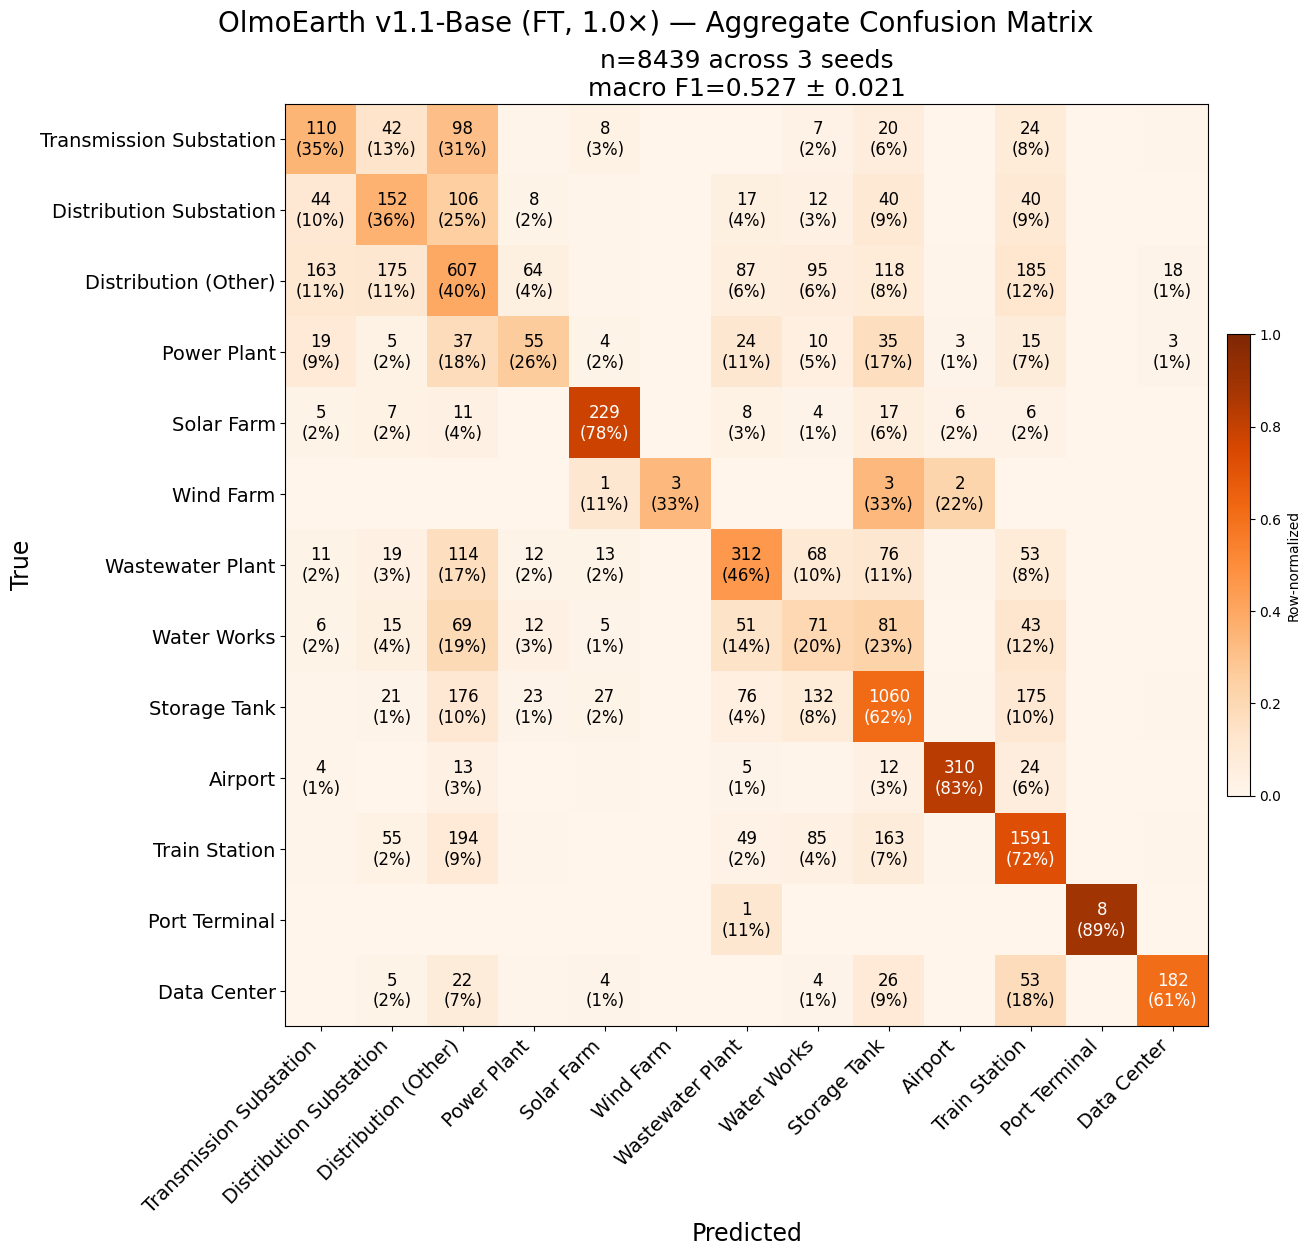


OlmoEarth v1.1-Base (FT, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.3350      0.3028      0.3094      0.3157 ± 0.0139
[ 1] energy.distribution.substation     0.3150      0.3492      0.3209      0.3284 ± 0.0149
[ 2] energy.distribution.other          0.4546      0.2427      0.4582      0.3852 ± 0.1008
[ 3] energy.generation.power_plant      0.2556      0.2667      0.2951      0.2725 ± 0.0166
[ 4] energy.generation.solar_farm       0.7826      0.7100      0.7653      0.7526 ± 0.0310
[ 5] energy.generation.wind_farm        0.5000      0.3333      0.5000      0.4444 ± 0.0786
[ 6] water.wastewater.plant             0.4563      0.4845      0.4798      0.4735 ± 0.0123
[ 7] water.water_works                  0.1627      0.1565      0.1938      0.1710 ± 0.0163
[ 8]

{314: {'cm': array([[ 34,  14,  39,   1,   0,   0,   0,   1,   9,   0,   6,   0,   1],
         [ 11,  43,  49,   2,   1,   0,   5,   3,  13,   0,  14,   0,   0],
         [ 38,  50, 258,  19,   1,   0,  22,  14,  42,   2,  60,   0,   5],
         [  4,   2,  17,  17,   1,   0,   7,   1,  15,   1,   4,   0,   1],
         [  1,   3,   7,   0,  72,   0,   5,   1,   7,   0,   2,   0,   0],
         [  0,   0,   0,   0,   0,   1,   0,   0,   2,   0,   0,   0,   0],
         [  4,   2,  54,   6,   1,   0,  94,  19,  29,   1,  18,   0,   0],
         [  1,   5,  30,   2,   1,   0,  14,  17,  33,   1,  14,   0,   0],
         [  2,   3,  75,   6,   7,   0,  21,  28, 358,   3,  69,   0,   2],
         [  0,   0,   6,   0,   1,   0,   2,   1,   3, 105,   7,   0,   0],
         [  3,   9,  80,   8,   1,   0,  14,   6,  45,   7, 560,   0,   4],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0],
         [  0,   1,   9,   2,   0,   0,   0,   0,  15,   0,  15,   0,  58]]),

In [9]:
confusion_matrix_aggregate('olmoearth', cmap='Oranges')

### DINOv3

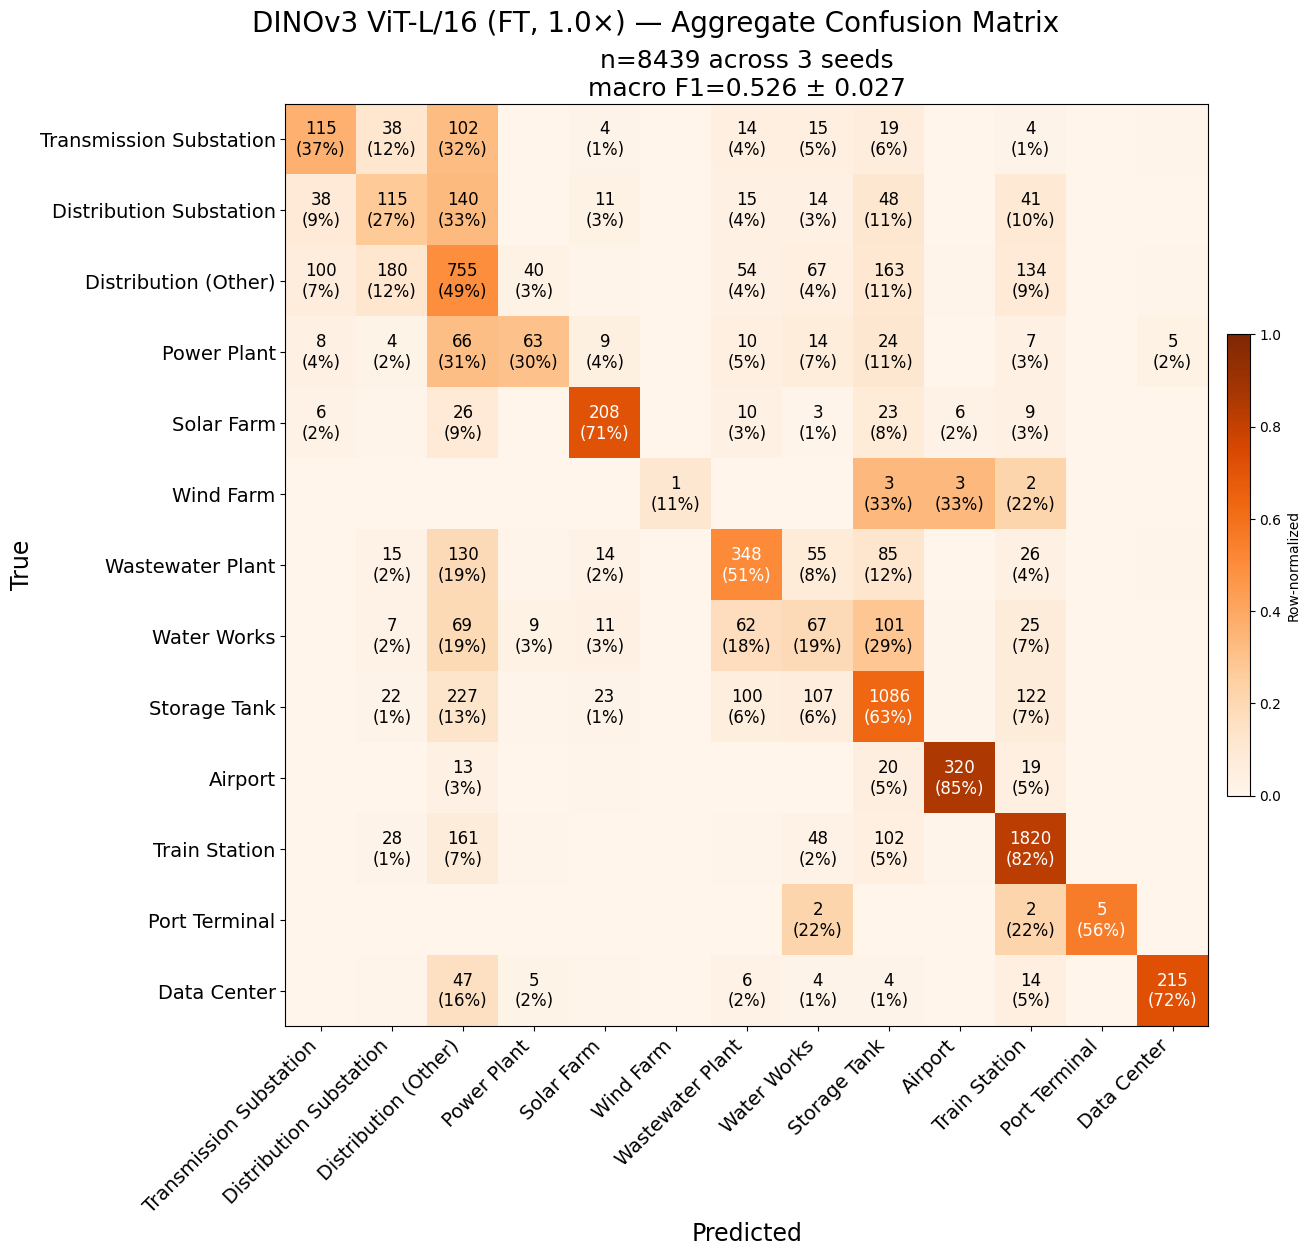


DINOv3 ViT-L/16 (FT, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.3616      0.4019      0.4000      0.3878 ± 0.0186
[ 1] energy.distribution.substation     0.2848      0.3071      0.2322      0.2747 ± 0.0314
[ 2] energy.distribution.other          0.4484      0.4711      0.4655      0.4617 ± 0.0096
[ 3] energy.generation.power_plant      0.3448      0.3333      0.3721      0.3501 ± 0.0163
[ 4] energy.generation.solar_farm       0.6979      0.6796      0.7208      0.6994 ± 0.0169
[ 5] energy.generation.wind_farm        0.0000      0.5000      0.0000      0.1667 ± 0.2357
[ 6] water.wastewater.plant             0.5370      0.5163      0.5354      0.5296 ± 0.0094
[ 7] water.water_works                  0.2164      0.2038      0.1014      0.1739 ± 0.0515
[ 8] wat

{314: {'cm': array([[ 32,  14,  37,   0,   2,   0,   7,   6,   7,   0,   0,   0,   0],
         [  9,  43,  46,   0,   3,   0,   4,   5,  19,   0,  12,   0,   0],
         [ 25,  76, 237,  14,   5,   0,  15,  22,  65,   2,  44,   0,   6],
         [  2,   2,  20,  20,   2,   0,   3,   5,  10,   0,   3,   0,   3],
         [  3,   1,   8,   1,  67,   0,   3,   3,   6,   2,   4,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,   0],
         [  0,   6,  36,   1,   3,   0, 116,  22,  34,   1,   8,   0,   1],
         [  0,   1,  21,   3,   3,   0,  20,  29,  33,   1,   7,   0,   0],
         [  1,   7,  72,   4,   7,   0,  31,  35, 374,   2,  40,   0,   1],
         [  0,   0,   3,   0,   2,   0,   0,   0,   8, 107,   5,   0,   0],
         [  0,  10,  54,   1,   0,   0,   2,  19,  39,   7, 602,   0,   3],
         [  0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   1,   1,   0],
         [  0,   1,  12,   2,   0,   0,   3,   3,   2,   0,   5,   0,  72]]),

In [10]:
confusion_matrix_aggregate('dinov3', cmap='Oranges')

### ResNet-18

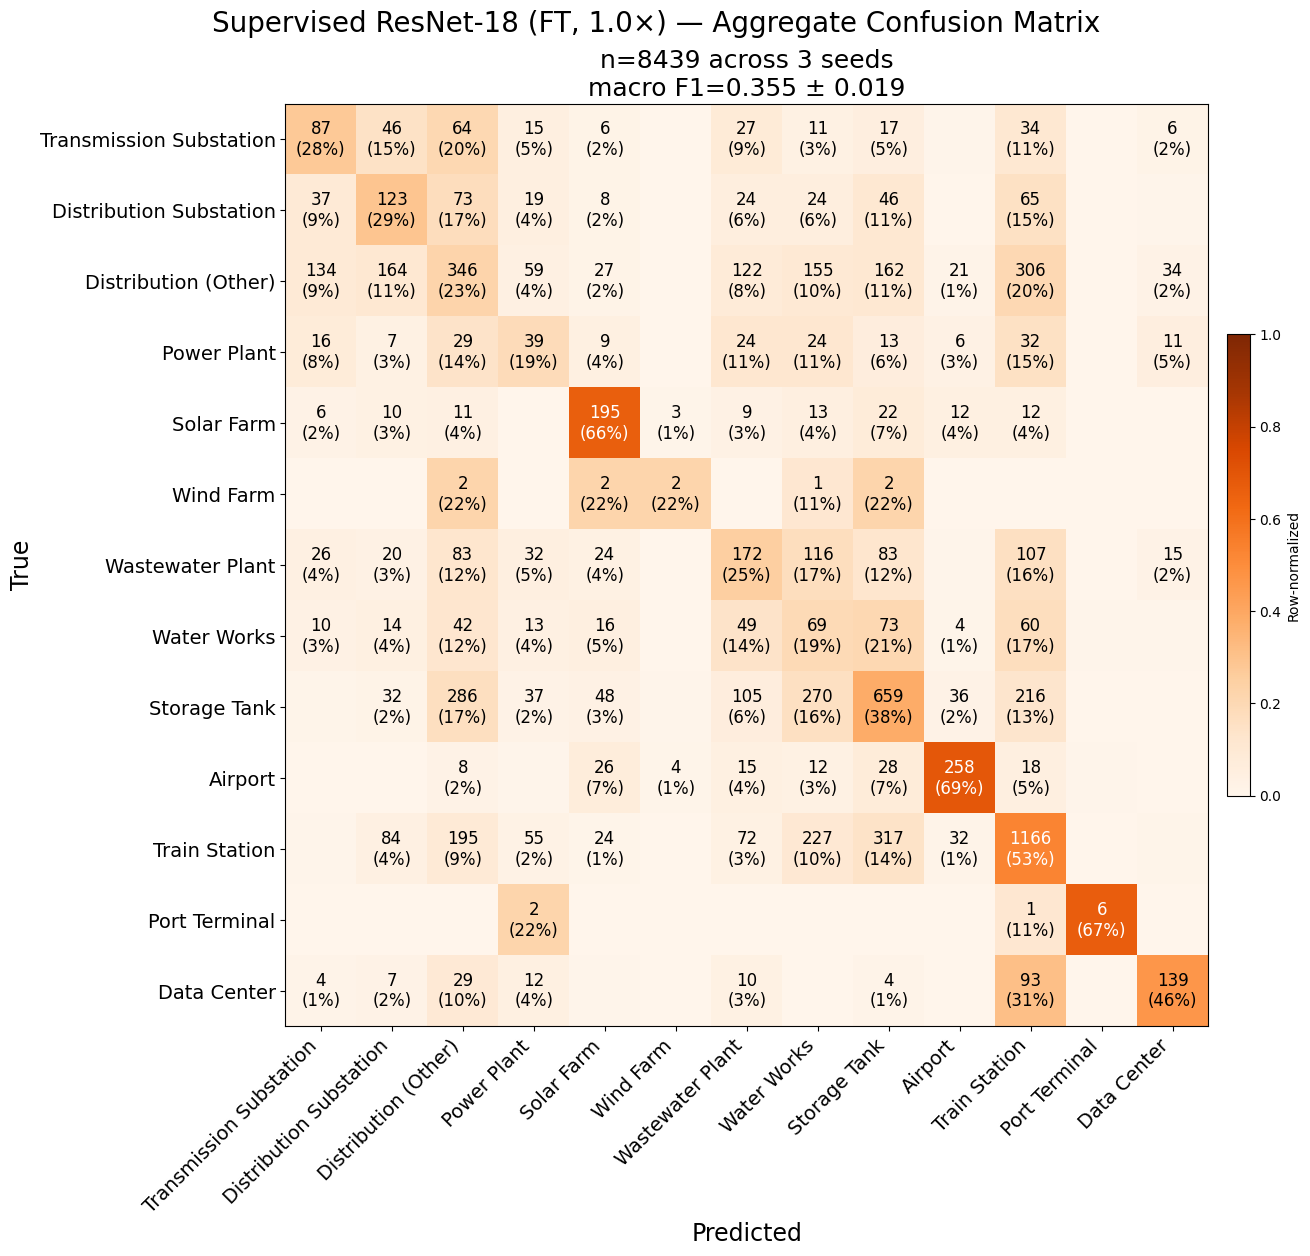


Supervised ResNet-18 (FT, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.2358      0.2920      0.2571      0.2617 ± 0.0232
[ 1] energy.distribution.substation     0.1873      0.2838      0.3047      0.2586 ± 0.0512
[ 2] energy.distribution.other          0.3205      0.2034      0.2209      0.2483 ± 0.0516
[ 3] energy.generation.power_plant      0.1196      0.1887      0.1748      0.1610 ± 0.0298
[ 4] energy.generation.solar_farm       0.5633      0.5648      0.5909      0.5730 ± 0.0127
[ 5] energy.generation.wind_farm        0.0000      0.2857      0.1111      0.1323 ± 0.1176
[ 6] water.wastewater.plant             0.2384      0.2400      0.2967      0.2584 ± 0.0271
[ 7] water.water_works                  0.1026      0.1217      0.1024      0.1089 ± 0.0091
[ 8

{314: {'cm': array([[ 27,  13,  32,   8,   3,   0,   4,   5,   4,   1,   7,   0,   1],
         [ 15,  25,  47,   5,   5,   0,   4,   9,  11,   1,  18,   0,   1],
         [ 50,  30, 175,  22,  10,   0,  22,  46,  56,   7,  82,   0,  11],
         [  9,   2,  16,  11,   2,   0,   4,   6,   8,   2,   7,   0,   3],
         [  2,   3,   4,   0,  69,   1,   1,   4,   8,   3,   3,   0,   0],
         [  0,   0,   1,   0,   2,   0,   0,   0,   0,   0,   0,   0,   0],
         [ 10,   6,  46,  14,  11,   0,  41,  37,  32,   0,  27,   1,   3],
         [  4,   6,  20,   8,   6,   0,   9,  20,  25,   0,  18,   2,   0],
         [  4,   9, 117,  18,  15,   1,  17,  73, 242,   5,  69,   2,   2],
         [  0,   0,   5,   1,  11,   0,   1,   3,  10,  86,   7,   1,   0],
         [  3,  29, 106,  22,  11,   0,   9,  69,  92,   9, 380,   3,   4],
         [  0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   2,   0],
         [  0,   3,  12,   4,   2,   0,   4,   0,   3,   0,  31,   0,  41]]),

In [25]:
confusion_matrix_aggregate('resnet', cmap='Oranges')

### Random Features

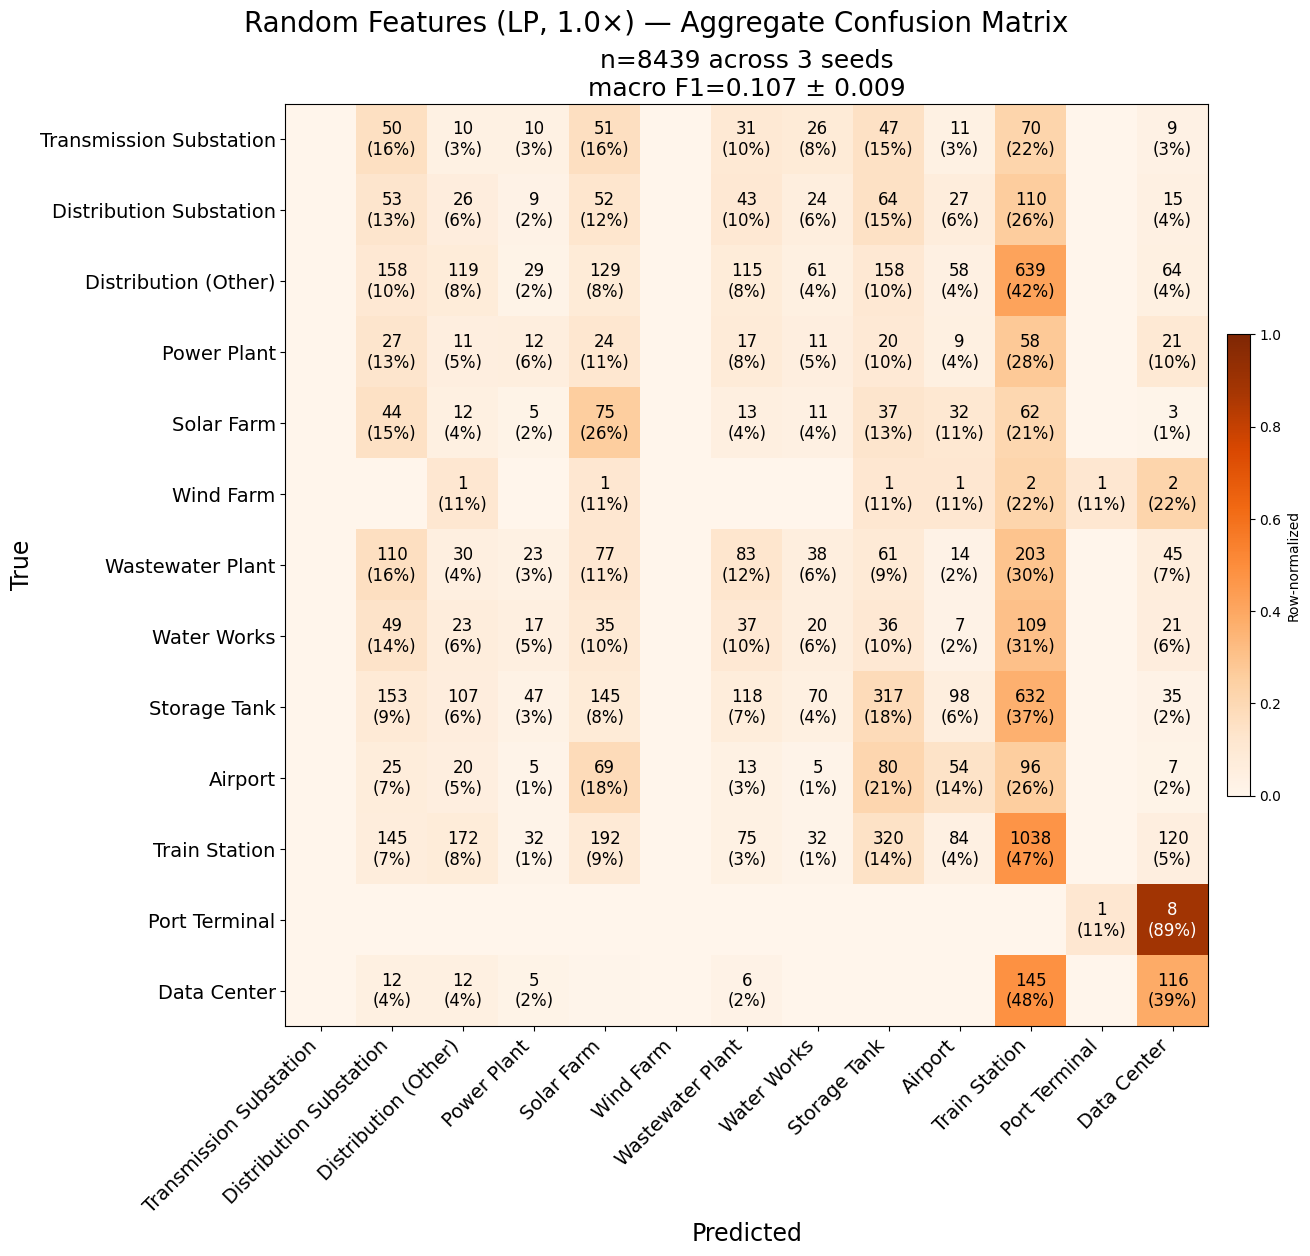


Random Features (LP, 1.0×) v2 — per-class F1 across 3 seed(s): [314, 271, 161]
    class                              seed 314    seed 271    seed 161    mean ± std
-----------------------------------------------------------------------------------------
[ 0] energy.transmission.substation     0.0000      0.0000      0.0000      0.0000 ± 0.0000
[ 1] energy.distribution.substation     0.0000      0.0000      0.1097      0.0366 ± 0.0517
[ 2] energy.distribution.other          0.0000      0.0000      0.2258      0.0753 ± 0.1064
[ 3] energy.generation.power_plant      0.1000      0.0521      0.0000      0.0507 ± 0.0408
[ 4] energy.generation.solar_farm       0.1325      0.1706      0.0000      0.1010 ± 0.0731
[ 5] energy.generation.wind_farm        0.0000      0.0000      0.0000      0.0000 ± 0.0000
[ 6] water.wastewater.plant             0.2070      0.0256      0.0000      0.0775 ± 0.0921
[ 7] water.water_works                  0.0000      0.0959      0.0000      0.0320 ± 0.0452
[ 8] wat

{314: {'cm': array([[  0,   0,   0,   4,  35,   0,  31,   0,   5,   0,  27,   0,   3],
         [  0,   0,   0,   1,  43,   0,  43,   0,   8,   0,  42,   0,   4],
         [  0,   0,   0,   9, 104,   0, 114,   0,  16,   0, 246,   3,  19],
         [  0,   0,   0,   7,  16,   0,  17,   0,   2,   0,  22,   0,   6],
         [  0,   1,   0,   2,  50,   0,  13,   0,   2,   0,  29,   0,   1],
         [  0,   0,   0,   0,   1,   0,   0,   0,   0,   0,   1,   1,   0],
         [  0,   0,   0,   8,  52,   0,  80,   0,   3,   0,  73,   0,  12],
         [  0,   0,   0,   2,  25,   0,  37,   0,   3,   0,  43,   0,   8],
         [  0,   0,   0,  12, 121,   0, 116,   0,  68,   0, 247,   0,  10],
         [  0,   0,   0,   4,  53,   0,  13,   0,   8,   0,  44,   1,   2],
         [  0,   0,   0,  18, 155,   0,  75,   0,  50,   0, 404,   1,  34],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   2],
         [  0,   0,   0,   3,   2,   0,   6,   0,   0,   0,  51,   0,  38]]),

In [14]:
confusion_matrix_aggregate('random_features', cmap='Oranges')

# Save all figures to disk (Task 3)

Regenerates and writes all 24 confusion matrix PNGs (6 aggregate + 18 per-seed) to each FM's results directory in Drive. Uses the updated `'Water Works'` display name and `'Oranges'` colormap. Filenames:

- `confusion_matrix_{file_prefix}_aggregate.png` — main-paper figures
- `confusion_matrix_{file_prefix}_seed{seed}.png` — appendix per-seed figures

Overwrites any existing PNGs at those paths (which is intentional — the old ones have the stale `'Treatment Plant'` label).

In [26]:
# Run once. Writes 24 PNGs to Drive under /content/drive/MyDrive/infra_fm/results/.
# Prints the path of each file it writes.
written = save_all_confusion_matrices()

  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_finetune_v1/confusion_matrix_satlas_s1_finetune_v1_seed314.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_finetune_v1/confusion_matrix_satlas_s1_finetune_v1_seed271.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_finetune_v1/confusion_matrix_satlas_s1_finetune_v1_seed161.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_finetune_v1/confusion_matrix_satlas_s1_finetune_v1_aggregate.png

  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s2_finetune_v1/confusion_matrix_satlas_s2_finetune_v1_seed314.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s2_finetune_v1/confusion_matrix_satlas_s2_finetune_v1_seed271.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s2_finetune_v1/confusion_matrix_satlas_s2_finetune_v1_seed161.png
  saved  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s2_finetune_v1/confusio

# Wall-clock backfill (Task 4: Appendix B Table 2)

Each per-seed results JSON contains `linear_probe.history[*].time_s` — the per-epoch wall clock recorded during training. Summing across the 25 epochs gives each seed's total training time; averaging across the 3 seeds gives the per-FM figure for Appendix B.

Hardware column is left as `TBD` because the JSON schema doesn't record the runtime GPU. Fill in `hardware={...}` before calling `print_wall_clock_table()` if you want it auto-populated (see the invocation cell below).

In [18]:
def _fmt_hms(seconds):
    """Format seconds as a compact human string: 's' / 'Xm Ys' / 'Xh Ym Zs'."""
    s = int(round(seconds))
    h, rem = divmod(s, 3600)
    m, s = divmod(rem, 60)
    if h > 0:
        return f'{h}h {m}m {s}s'
    if m > 0:
        return f'{m}m {s}s'
    return f'{s}s'


def load_wall_clocks(fms=None, seeds=None):
    """Sum per-epoch `time_s` from each per-seed JSON's `linear_probe.history`.

    Returns
    -------
    dict[fm_key -> dict] with keys:
        'per_seed'  : {seed: total_seconds, ...}
        'mean_s'    : mean across available seeds (float)
        'total_s'   : sum across available seeds (float)
        'n_epochs'  : {seed: len(history), ...}
        'available' : list of seeds actually found
        'missing'   : list of seeds not found
        'label'     : FM display label
    """
    if fms is None:
        fms = list(FM_CONFIGS.keys())
    if seeds is None:
        seeds = DEFAULT_SEEDS

    out = {}
    for fm in fms:
        subdir, file_prefix, fm_label, _ = FM_CONFIGS[fm]
        results_dir = RESULTS_BASE / subdir
        per_seed = {}
        n_epochs = {}
        missing = []
        for seed in seeds:
            p = results_dir / f'{file_prefix}_seed{seed}_results.json'
            if not p.exists():
                missing.append(seed)
                continue
            with p.open() as f:
                r = json.load(f)
            history = r.get('linear_probe', {}).get('history', [])
            per_seed[seed] = sum(float(e.get('time_s', 0.0)) for e in history)
            n_epochs[seed] = len(history)

        if per_seed:
            times = list(per_seed.values())
            mean_s = float(np.mean(times))
            total_s = float(np.sum(times))
        else:
            mean_s = 0.0
            total_s = 0.0
        out[fm] = {
            'per_seed': per_seed,
            'mean_s':   mean_s,
            'total_s':  total_s,
            'n_epochs': n_epochs,
            'available': sorted(per_seed.keys()),
            'missing':  missing,
            'label':    fm_label,
        }
    return out


def print_wall_clock_table(fms=None, seeds=None, hardware=None):
    """Print a paste-ready markdown table of per-FM training wall clocks.

    Parameters
    ----------
    hardware : dict[str, str] or None
        Optional mapping fm_key -> hardware string. FM keys with no entry
        get 'TBD'. Example:
            {'croma': 'Colab L4 (24 GB)', 'alphaearth': 'CPU (precomputed embeddings)'}
    """
    if seeds is None:
        seeds = DEFAULT_SEEDS
    if hardware is None:
        hardware = {}

    data = load_wall_clocks(fms=fms, seeds=seeds)

    # Header
    seed_cols = ' | '.join([f'Seed {s}' for s in seeds])
    print(f'| FM | Hardware | {seed_cols} | Mean per seed | Total (3 seeds) |')
    print('|---|---|' + ('---:|' * len(seeds)) + '---:|---:|')

    # Rows (preserve FM_CONFIGS insertion order)
    for fm, d in data.items():
        cells = []
        for s in seeds:
            v = d['per_seed'].get(s)
            cells.append(_fmt_hms(v) if v is not None else '—')
        row = (f"| {d['label']} | {hardware.get(fm, 'TBD')} | "
               + ' | '.join(cells)
               + f" | {_fmt_hms(d['mean_s'])} | {_fmt_hms(d['total_s'])} |")
        print(row)

    # Diagnostics
    print()
    for fm, d in data.items():
        if d['missing']:
            print(f'NOTE: {d["label"]} missing seeds {d["missing"]} — cells show "—".')
        # Sanity-check epoch counts if we have any
        if d['n_epochs']:
            counts = set(d['n_epochs'].values())
            if len(counts) > 1:
                print(f'NOTE: {d["label"]} has uneven epoch counts across seeds: '
                      f'{d["n_epochs"]}')

    print()
    print('(Hardware column defaults to "TBD" — fill in per-FM by passing e.g.')
    print(' hardware={"croma": "Colab L4 (24 GB)", "alphaearth": "CPU"} to this function.)')
    return data

In [19]:
# Fill this in with what you actually used on each Colab run.
# Any FM key you omit will render as 'TBD' in the table.
hardware = {
    'satlas_s1':       'Colab A100 (80 GB)',
    'satlas_s2':       'Colab A100 (80 GB)',
    'croma':           'Colab A100 (80 GB)',
    'prithvi':         'Colab A100 (80 GB)',
    'alphaearth':      'Colab L4 (24 GB)',
    'olmoearth':       'Colab A100 (40 GB)',
    'dinov3':          'Colab A100 (80 GB)',
    'resnet':          'Colab A100 (80 GB)',
    'random_features': 'Colab A100 (80 GB)',
}

wall_clock_data = print_wall_clock_table(hardware=hardware)

ValueError: too many values to unpack (expected 4)

# Training dynamics overlay (exploratory)

Overlay validation macro-F1 vs epoch for all six FMs on a single subplot, mean ± 1 std band across the three seeds. Each FM gets a star marker at its best-val-F1 epoch (mean across seeds, positioned at the mean val-F1 at that epoch) — this is the "best-checkpoint-before-test" epoch that was restored before the test evaluation.

Reads `linear_probe.history[*].val_macro_f1` from each per-seed JSON. Handles missing seeds and uneven epoch counts gracefully (diagnostics print below the plot).

**Purpose:** decide the final figure design (single overlay vs. small-multiples grid vs. Prithvi-focused) before committing to a manuscript figure.

In [20]:
# Fixed per-FM colors for training-dynamics plots. Keeps each FM's identity
# stable across figures regardless of legend ordering (which is
# peak-F1-descending and shifts with the metric).
#   Prithvi   -> purple    SatlasS2  -> blue     SatlasS1 -> brown
#   CROMA     -> orange    ResNet-18 -> red      AlphaEarth -> green
_TAB10 = plt.get_cmap('tab10').colors
FM_COLORS = {
    'prithvi':    _TAB10[4],   # purple
    'satlas_s2':  _TAB10[0],   # blue
    'satlas_s1':  _TAB10[5],   # brown
    'croma':      _TAB10[1],   # orange
    'resnet':     _TAB10[3],   # red
    'alphaearth': _TAB10[2],   # green
}


def load_training_curves(fms=None, seeds=None, metric='val_macro_f1'):
    """Load a single per-epoch metric across all FMs and seeds.

    Returns
    -------
    dict[fm_key -> dict] with keys:
        'per_seed'    : {seed: np.ndarray of shape (n_epochs,), ...}
        'mean'        : np.ndarray of shape (min_n_epochs,)  — mean across seeds
        'std'         : np.ndarray of shape (min_n_epochs,)  — std across seeds (ddof=0)
        'epochs'      : np.ndarray of shape (min_n_epochs,)  — 1-indexed
        'best_epoch_per_seed' : {seed: int}  — 1-indexed epoch with max val_macro_f1
        'best_epoch_mean'     : int          — rounded mean of per-seed best epochs
        'label'       : FM display label
        'missing'     : list of seeds not found
        'uneven'      : True if seeds had different history lengths
    """
    if fms is None:
        fms = list(FM_CONFIGS.keys())
    if seeds is None:
        seeds = DEFAULT_SEEDS

    out = {}
    for fm in fms:
        subdir, prefix, label, _ = FM_CONFIGS[fm]
        results_dir = RESULTS_BASE / subdir

        per_seed_curve = {}
        best_epoch_per_seed = {}
        missing = []
        lengths = set()
        # best epoch always uses val_macro_f1 (matches BEST_CKPT_BEFORE_TEST)
        for seed in seeds:
            p = results_dir / f'{prefix}_seed{seed}_results.json'
            if not p.exists():
                missing.append(seed)
                continue
            with p.open() as f:
                r = json.load(f)
            history = r.get('linear_probe', {}).get('history', [])
            if not history:
                missing.append(seed)
                continue
            vals   = np.array([float(e.get(metric, np.nan)) for e in history])
            val_f1 = np.array([float(e.get('val_macro_f1', np.nan))
                                for e in history])
            per_seed_curve[seed] = vals
            best_epoch_per_seed[seed] = int(np.nanargmax(val_f1)) + 1  # 1-indexed
            lengths.add(len(history))

        if not per_seed_curve:
            out[fm] = {
                'per_seed': {}, 'mean': None, 'std': None, 'epochs': None,
                'best_epoch_per_seed': {}, 'best_epoch_mean': None,
                'label': label, 'missing': missing, 'uneven': False,
            }
            continue

        min_len = min(len(v) for v in per_seed_curve.values())
        stacked = np.stack([v[:min_len] for v in per_seed_curve.values()], axis=0)
        mean    = stacked.mean(axis=0)
        std     = stacked.std(axis=0, ddof=0)
        epochs  = np.arange(1, min_len + 1)
        best_mean = int(round(float(np.mean(list(best_epoch_per_seed.values())))))

        out[fm] = {
            'per_seed': per_seed_curve,
            'mean':     mean,
            'std':      std,
            'epochs':   epochs,
            'best_epoch_per_seed': best_epoch_per_seed,
            'best_epoch_mean':     best_mean,
            'label':    label,
            'missing':  missing,
            'uneven':   len(lengths) > 1,
        }
    return out


def plot_training_dynamics_overlay(
    fms=None, seeds=None, metric='val_macro_f1',
    save_path=None, show=True, figsize=(12, 7),
):
    """Overlay per-epoch metric (mean ± std) for all FMs on a single subplot.

    Colors are fixed per FM via FM_COLORS. Legend order is peak-mean-metric
    descending, so the highest-performing FM appears at the top of the
    legend (matches the visual reading order top-to-bottom).

    Star marker at each FM's best-checkpoint epoch (mean of per-seed
    argmax(val_macro_f1) — the epoch that BEST_CKPT_BEFORE_TEST restores).

    Parameters
    ----------
    fms : list[str] or None
        FM keys to plot. Defaults to all six.
    seeds : list[int] or None
        Seeds to aggregate over. Defaults to [314, 271, 161].
    metric : str
        History key. Default 'val_macro_f1'.
    save_path : str/Path or None
        If provided, saves the figure to this path (dpi=150, bbox='tight').
    show : bool
        Whether to plt.show() the figure inline.
    figsize : tuple
        Figure size in inches. Default (12, 7).

    Returns
    -------
    (fig, curves) : (matplotlib.figure.Figure, dict from load_training_curves)
    """
    if fms is None:
        fms = list(FM_CONFIGS.keys())
    if seeds is None:
        seeds = DEFAULT_SEEDS

    curves = load_training_curves(fms=fms, seeds=seeds, metric=metric)

    fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

    def _sort_key(fm):
        c = curves[fm]
        if c['mean'] is None:
            return -np.inf
        return float(np.nanmax(c['mean']))

    fms_ordered = sorted(fms, key=_sort_key, reverse=True)

    diagnostics = []
    for fm in fms_ordered:
        c = curves[fm]
        color = FM_COLORS.get(fm, 'gray')
        if c['mean'] is None:
            diagnostics.append(f'{c["label"]}: no seeds available; skipped')
            continue
        if c['missing']:
            diagnostics.append(f'{c["label"]}: missing seeds {c["missing"]}')
        if c['uneven']:
            lengths = {s: len(v) for s, v in c['per_seed'].items()}
            diagnostics.append(f'{c["label"]}: uneven epoch counts {lengths}; '
                                f'truncated to {len(c["mean"])}')

        ax.plot(c['epochs'], c['mean'], color=color, linewidth=2.0,
                 label=c['label'], zorder=3)
        ax.fill_between(c['epochs'], c['mean'] - c['std'], c['mean'] + c['std'],
                         color=color, alpha=0.15, linewidth=0, zorder=2)

        be = c['best_epoch_mean']
        if be is not None and 1 <= be <= len(c['mean']):
            ax.scatter([be], [c['mean'][be - 1]],
                        marker='*', s=220, color=color,
                        edgecolor='white', linewidth=1.4, zorder=5)

    metric_label = {
        'val_macro_f1': 'Validation macro F1',
        'val_acc':      'Validation accuracy',
        'train_loss':   'Training loss',
    }.get(metric, metric)

    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel(metric_label, fontsize=16)
    ax.set_title('Training dynamics across foundation models\n'
                 f'{metric_label}, mean ± 1 std across seeds; '
                 f'★ = best-checkpoint epoch',
                 fontsize=18)
    ax.tick_params(labelsize=14)
    ax.set_xlim(0.5, 25.5)
    if metric != 'train_loss':
        ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

    ax.legend(loc='lower right', fontsize=12, framealpha=0.92,
              title='Foundation model', title_fontsize=12)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')

    if show:
        plt.show()

    if diagnostics:
        print('\n--- Diagnostics ---')
        for d in diagnostics:
            print(f'  {d}')

    print('\n--- Best-checkpoint epochs (val macro F1 argmax) ---')
    for fm in fms_ordered:
        c = curves[fm]
        if not c['best_epoch_per_seed']:
            continue
        per = c['best_epoch_per_seed']
        peak = float(np.nanmax(c['mean'])) if c['mean'] is not None else float('nan')
        print(f'  {c["label"]:<26s}  per-seed: {per}   '
              f'mean best epoch: {c["best_epoch_mean"]:>2d}   '
              f'peak mean F1: {peak:.3f}')

    return fig, curves

In [21]:
# Option B (final): single overlay of all six FMs, val_macro_f1 only.
# Renders inline AND saves to Drive as the Appendix A figure.
# File: /content/drive/MyDrive/infra_fm/results/appendix_A_training_dynamics_overlay.png
fig, curves = plot_training_dynamics_overlay(
    save_path=RESULTS_BASE / 'appendix_A_training_dynamics_overlay.png',
)

ValueError: too many values to unpack (expected 4)